In [1]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.decomposition import PCA


In [2]:
nltk.download('punkt')
nltk.download('stopwords')

def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return tokens

[nltk_data] Downloading package punkt to /Users/can/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/can/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return tokens

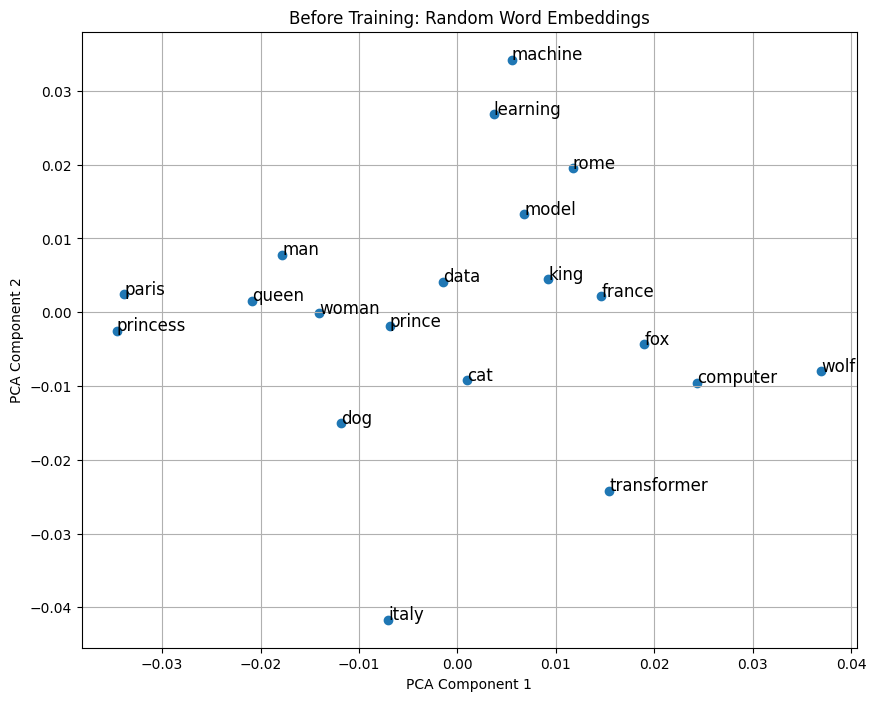

In [ ]:
random_model = Word2Vec(
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

with open("data.txt", "r", encoding="UTF-8") as f:
    data = f.readlines()


preprocessed_sentences = [preprocess_text(sentence) for sentence in data]

random_model.build_vocab(preprocessed_sentences)

words_to_plot = [
    "king", "queen", "prince", "princess", "man", "woman", "boy", "girl",
    "paris", "france", "rome", "italy",
    "dog", "cat", "wolf", "fox",
    "computer", "machine", "data", "model", "learning", "transformer"
]

words = [w for w in words_to_plot if w in random_model.wv]

word_vectors = random_model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

plt.figure(figsize=(10, 8))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)

plt.title("Before Training: Random Word Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()

In [5]:
# Train Word2Vec model
trained_model = Word2Vec(
    sentences=preprocessed_sentences,
    vector_size=100,
    window=3,
    min_count=1,
    workers=1,
    sg=1,
    seed=42,
    epochs=200
)


# Save trained model
trained_model.save("word2vec_trained.model")

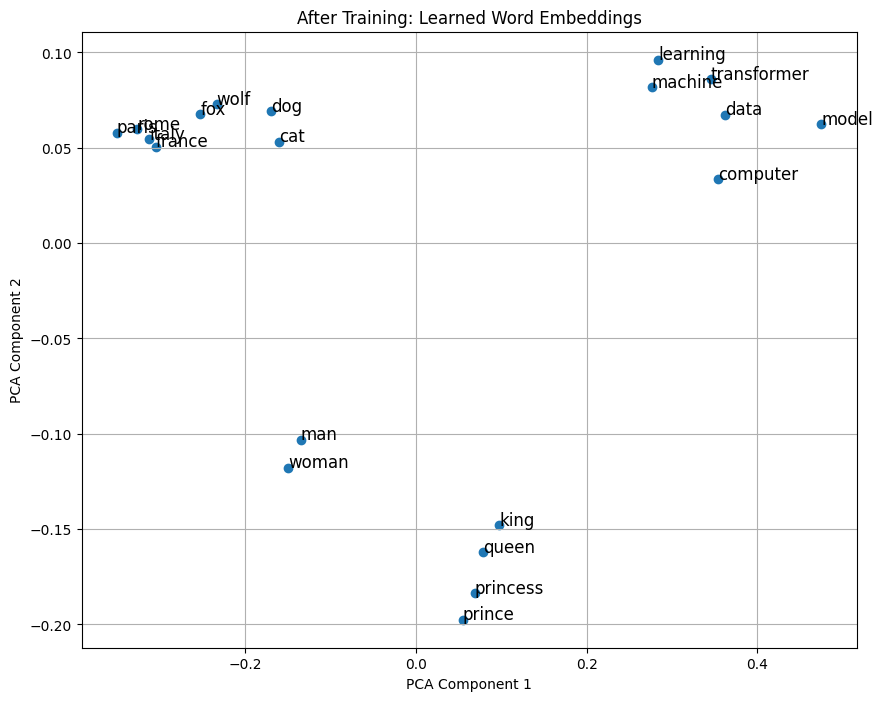

In [6]:
words_to_plot = [
    "king", "queen", "prince", "princess", "man", "woman", "boy", "girl",
    "paris", "france", "rome", "italy",
    "dog", "cat", "wolf", "fox",
    "computer", "machine", "data", "model", "learning", "transformer"
]

words = [w for w in words_to_plot if w in trained_model.wv]
word_vectors = trained_model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

plt.figure(figsize=(10, 8))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)

plt.title("After Training: Learned Word Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()

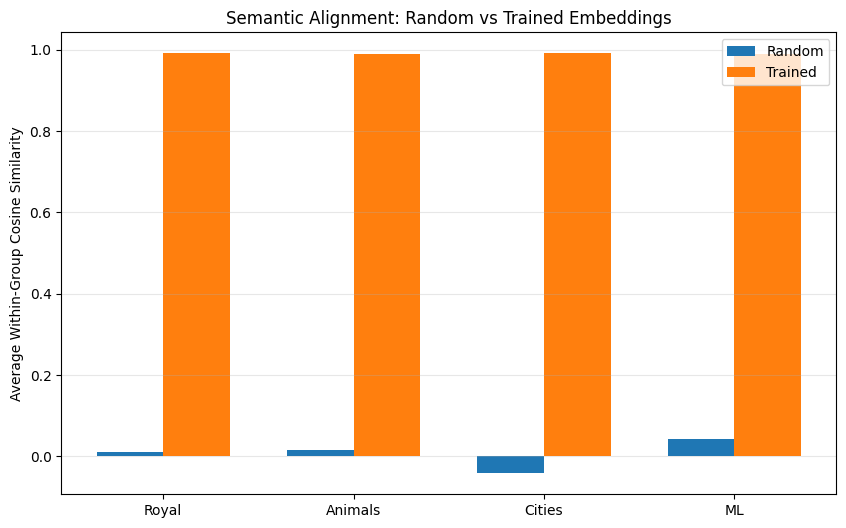

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

groups = {
    "Royal": ["king", "queen", "prince", "princess", "man", "woman"],
    "Animals": ["dog", "cat", "wolf", "fox"],
    "Cities": ["paris", "france", "rome", "italy"],
    "ML": ["computer", "machine", "data", "model", "learning", "transformer"]
}

def avg_within_group_similarity(model, group_words):
    words = [w for w in group_words if w in model.wv]

    if len(words) < 2:
        return np.nan

    vectors = model.wv[words]
    sim = cosine_similarity(vectors)

    upper_triangle = sim[np.triu_indices_from(sim, k=1)]
    return upper_triangle.mean()

random_scores = []
trained_scores = []
labels = []

for group_name, group_words in groups.items():
    labels.append(group_name)
    random_scores.append(avg_within_group_similarity(random_model, group_words))
    trained_scores.append(avg_within_group_similarity(trained_model, group_words))

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, random_scores, width, label="Random")
plt.bar(x + width/2, trained_scores, width, label="Trained")

plt.xticks(x, labels)
plt.ylabel("Average Within-Group Cosine Similarity")
plt.title("Semantic Alignment: Random vs Trained Embeddings")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()
